<a href="https://colab.research.google.com/github/adytriaby/PCVK_Ganjil2026/blob/main/week1_PCVK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

D2. Pengenalan Python untuk membaca dan menampilkan image dengan
pengenalan macam-macam Library (Numpy, pandas, cv2, skimage, PIL dan
matplotlib)


Langkah 1: Import Library yang Dibutuhkan



In [ ]:
import numpy as np
import pandas as pd
import cv2 as cv
from google.colab.patches import cv2_imshow # for image display
from skimage import io
from skimage import transform
from PIL import Image
import matplotlib.pylab as plt

Langkah 2: Membaca dan Menampilkan Image dari URLs

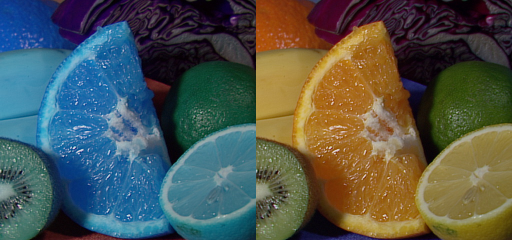

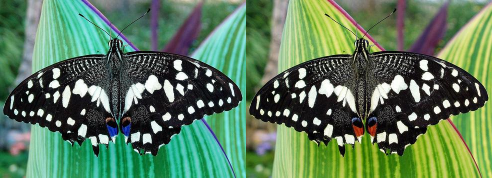

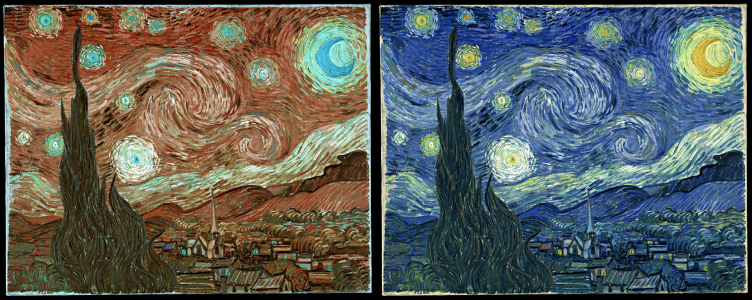

In [ ]:
# Membuat list untuk menyimpan url dari beberapa image
imageurls = [
    "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/fruits.jpg",
    "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/butterfly.jpg",
    "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/starry_night.jpg",
]
# baca dan tampilkan image
# loop pada tiap url image, beberapa image dapat disimpan pada list
for url in imageurls:
    image = io.imread(url)                               #read image
    image = cv.resize(image, (0,0), fx=0.5, fy=0.5)      #resize image to half size
    image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)       #convert color to RGB
    final_frame = cv.hconcat((image, image_2))           #concatenate image
    cv2_imshow(final_frame)                              #show image
    print('\n')

Langkah 3: Melihat Ukuran Resolusi File Image

resolusi image: tinggi x lebar =  300  x  376


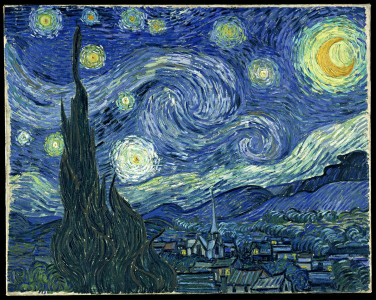

In [ ]:
tinggi = image_2.shape[0]
lebar = image_2.shape[1]
print("resolusi image: tinggi x lebar = ",tinggi," x ", lebar)
cv2_imshow(image_2)

Langkah 4: Mengakses Pixel untuk Membuat Garis Horizontal

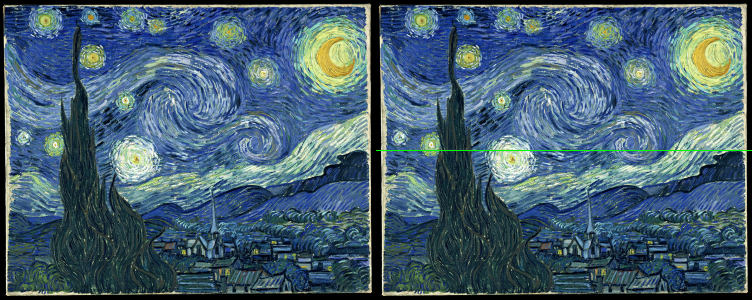

In [ ]:
# Tambahkan baris ini agar image_3 dikenali
image_3 = image_2.copy()

row = int(image_3.shape[0] / 2)
#garis horizontal di tengah image tanpa loop
#image_3 [int(image.shape[0]/2), :]=[0,255,0]

#membuat garis horizontal di tengah image dengan loop
for x in range(image_3.shape[1]):
    image_3 [row, x] = [0, 255, 0]
    # jalan menyusuri kolom

final_frame = cv.hconcat((image_2, image_3))
cv2_imshow(final_frame)

PERTANYAAN PRAKTIKUM D2

1. Alasan Eksekusi Kode Menggunakan Google Colab
Google Colab sering digunakan dalam praktikum pengolahan citra karena menyediakan lingkungan Jupyter Notebook berbasis cloud yang siap pakai. Mahasiswa tidak perlu melakukan instalasi Python atau mengonfigurasi library berat secara lokal di komputer masing-masing. Selain itu, Colab menyediakan akses komputasi tingkat tinggi (seperti GPU/TPU) secara gratis yang sangat mempercepat proses komputasi image processing.

2. Kegunaan Library pada Praktikum (Asumsi library standar)
(Catatan: Karena detail langkah ke-8 tidak terlihat di gambar "image_6c3604.png", berikut adalah penjelasan untuk library pengolahan citra yang umum digunakan pada modul serupa).

cv2 (OpenCV): Library utama untuk membaca, memproses, dan memanipulasi citra digital.

numpy: Digunakan untuk komputasi matriks/array, karena gambar pada dasarnya direpresentasikan sebagai matriks angka (nilai pixel).

matplotlib.pyplot: Digunakan untuk visualisasi atau menampilkan plot gambar ke layar.
Apakah semua harus digunakan? Tidak selalu. Tergantung pada baris kode di sesi tersebut. Jika program hanya memanipulasi gambar dan menyimpannya ke direktori tanpa perlu menampilkannya di output cell, maka matplotlib tidak wajib diimpor.

3. Kegunaan cv.resize dan Pengaruhnya

Kegunaan: Potongan kode cv.resize(image, (0,0), fx=0.5, fy=0.5) berfungsi untuk mengecilkan ukuran (scale down) gambar menjadi 50% atau setengah dari ukuran aslinya. Parameter fx=0.5 dan fy=0.5 adalah faktor skala untuk sumbu X (lebar) dan sumbu Y (tinggi).

Pengaruh jika tidak dilakukan: Gambar akan tetap berada di resolusi aslinya. Jika ukuran gambar asli sangat besar, hal ini dapat menyebabkan proses komputasi algoritma menjadi jauh lebih lambat, memakan banyak memori RAM, dan menyulitkan visualisasi utuh pada layar monitor.

4. Kegunaan Kode [0, 255, 0]
Kode tersebut merepresentasikan nilai warna sebuah pixel. OpenCV secara default membaca citra berwarna dalam format saluran BGR (Blue, Green, Red), bukan RGB.
Nilai [0, 255, 0] berarti:

Biru (B) = 0

Hijau (G) = 255 (intensitas maksimal)

Merah (R) = 0
Sehingga, kode di dalam loop tersebut digunakan untuk mewarnai baris pixel spesifik menjadi warna hijau guna membentuk garis horizontal.

5. Keterkaitan Pixel dan Resolusi Gambar

Pixel (Picture Element) adalah titik atau elemen warna terkecil yang menyusun sebuah citra digital.

Resolusi adalah ukuran dimensi gambar yang dihitung dari total kerapatan dan jumlah pixel (misal: 1920 x 1080 pixel).

Keterkaitan: Gambar beresolusi tinggi tersusun dari jumlah pixel yang sangat banyak, sehingga mampu menyimpan detail informasi gambar yang lebih kompleks dan terlihat tajam/halus. Sebaliknya, gambar beresolusi rendah hanya memiliki sedikit pixel. Apabila gambar resolusi rendah diperbesar (zoom in), setiap pixel akan dipaksa melebar sehingga gambar akan terlihat pecah dan kotak-kotak (pixelated).

TUGAS PRAKTIKUM D2


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from PIL import Image


1. membaca gambar


In [10]:
url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/fruits.jpg"

response = requests.get(url)
image = Image.open(BytesIO(response.content)).convert("RGB")
image = np.array(image)

tinggi, lebar, channel = image.shape

print("Resolusi gambar :", f"{lebar} x {tinggi}")
print("Jumlah channel  :", channel)
print("Jumlah pixel    :", tinggi * lebar)

Resolusi gambar : 512 x 480
Jumlah channel  : 3
Jumlah pixel    : 245760


2. Garis VERTIKAL

In [11]:
img_vertikal = image.copy()

x = lebar // 2
img_vertikal[:, x] = [0, 255, 0]


3. Garis DIAGONAL

In [12]:
img_diagonal = image.copy()

for i in range(min(tinggi, lebar)):
    img_diagonal[i, i] = [0, 255, 0]
    img_diagonal[i, lebar - 1 - i] = [0, 255, 0]

4. Garis HORIZONTAL MERAH

In [13]:
img_horizontal = image.copy()

y = tinggi // 2
panjang = 300

x_awal = (lebar - panjang) // 2
x_akhir = x_awal + panjang

img_horizontal[y, x_awal:x_akhir] = [255, 0, 0]

5. Kotak PUTIH

In [14]:
img_kotak = image.copy()

x1, y1 = 100, 100
x2, y2 = 300, 250

img_kotak[y1:y2, x1:x2] = [255, 255, 255]

6. Tampilankan Hasil

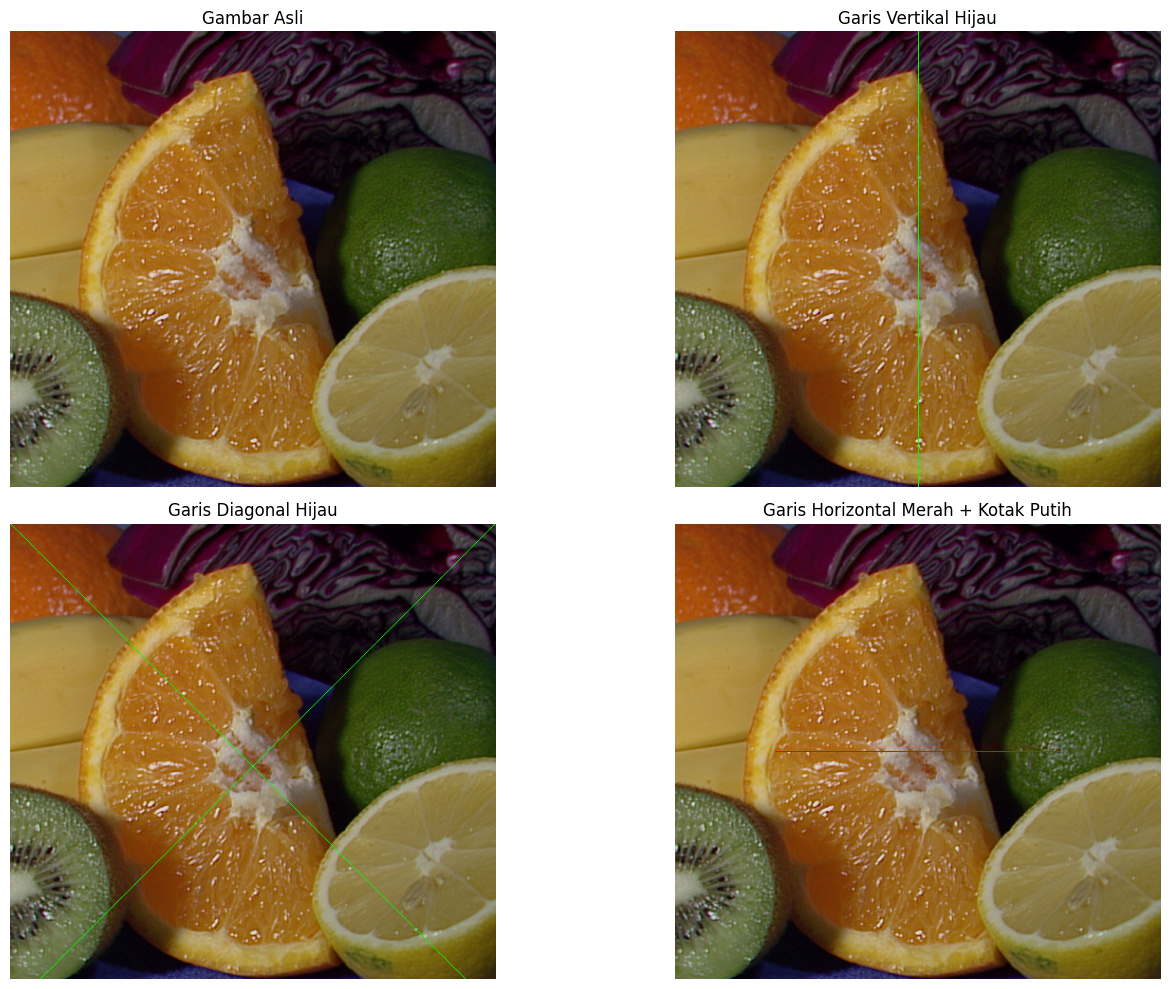

In [15]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(image)
plt.title("Gambar Asli")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(img_vertikal)
plt.title("Garis Vertikal Hijau")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(img_diagonal)
plt.title("Garis Diagonal Hijau")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(img_horizontal)
plt.title("Garis Horizontal Merah + Kotak Putih")
plt.axis("off")

plt.tight_layout()
plt.show()